# Periodic Lattice Performance

Use this notebook after a training run to inspect how the U-Net behaves on cubic and hexagonal periodic lattice datasets.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    matplotlib.use("Agg")
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "GombNet").exists() and (REPO_ROOT.parent / "GombNet").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from GombNet.metrics import evaluate_heatmap_localization
from GombNet.networks import build_unet
from GombNet.synthetic import (
    PeriodicLatticeConfig,
    RandomMicroscopeImageConfig,
    generate_microscope_image,
    metadata_collate,
    plot_microscope_image,
    SyntheticMicroscopeDataset,
)
from GombNet.utils import resolve_torch_device

print(f"repo: {REPO_ROOT}")
print(f"python: {sys.executable}")
print(f"torch: {torch.__version__}")
print(f"mps available: {torch.backends.mps.is_available() if hasattr(torch.backends, 'mps') else False}")

repo: /Users/austin/Documents/GitHub/BlobNet
python: /Users/austin/Documents/GitHub/BlobNet/.venv/bin/python
torch: 2.11.0
mps available: True


## Settings

In [2]:
RUN_DIR = Path("/tmp/blobnet_run")
MODEL_NAME = "unet"
DEVICE = "auto"

IMAGE_SHAPE = (256, 256)
NUM_FILTERS = [32, 64, 128, 256]
DROPOUT = 0.2

THRESHOLD_REL = 0.35
MATCH_DISTANCE = 3.0
PERIODIC_SAMPLES = 64
BATCH_SIZE = 4
SEED = 130

training_config = RandomMicroscopeImageConfig(
    image_shape=IMAGE_SHAPE,
    min_atoms=120,
    max_atoms=180,
    min_separation=10.0,
    min_separation_range=(9.0, 12.0),
    sigma_range=(1.8, 3.2),
    background_range=(0.0, 0.30),
    low_frequency_noise_range=(0.08, 0.30),
    read_noise_std_range=(0.0, 0.0),
    total_counts_range=(7500.0, 7500.0),
    blur_sigma_range=(0.3, 1.1),
    edge_padding=24,
)

periodic_common = dict(
    image_shape=IMAGE_SHAPE,
    lattice_spacing_range=(9.0, 12.0),
    jitter_std_range=(0.0, 0.15),
    vacancy_fraction_range=(0.0, 0.02),
    sigma_range=training_config.sigma_range,
    intensity_range=training_config.intensity_range,
    target_sigma=training_config.target_sigma,
    background_range=training_config.background_range,
    gradient_range=training_config.gradient_range,
    low_frequency_noise_range=training_config.low_frequency_noise_range,
    low_frequency_sigma_fraction_range=training_config.low_frequency_sigma_fraction_range,
    read_noise_std_range=training_config.read_noise_std_range,
    total_counts_range=training_config.total_counts_range,
    counts_per_pixel_range=training_config.counts_per_pixel_range,
    blur_sigma_range=training_config.blur_sigma_range,
    edge_padding=training_config.edge_padding,
    min_atoms=80,
)

checkpoint_path = RUN_DIR / MODEL_NAME / f"{MODEL_NAME}_best.pth"
history_path = RUN_DIR / MODEL_NAME / f"{MODEL_NAME}_loss_history.npz"
output_dir = RUN_DIR / "periodic_lattice_notebook"
output_dir.mkdir(parents=True, exist_ok=True)

print(f"checkpoint: {checkpoint_path}")
print(f"loss history: {history_path}")

checkpoint: /tmp/blobnet_run/unet/unet_best.pth
loss history: /tmp/blobnet_run/unet/unet_loss_history.npz


## Training Dataset Example

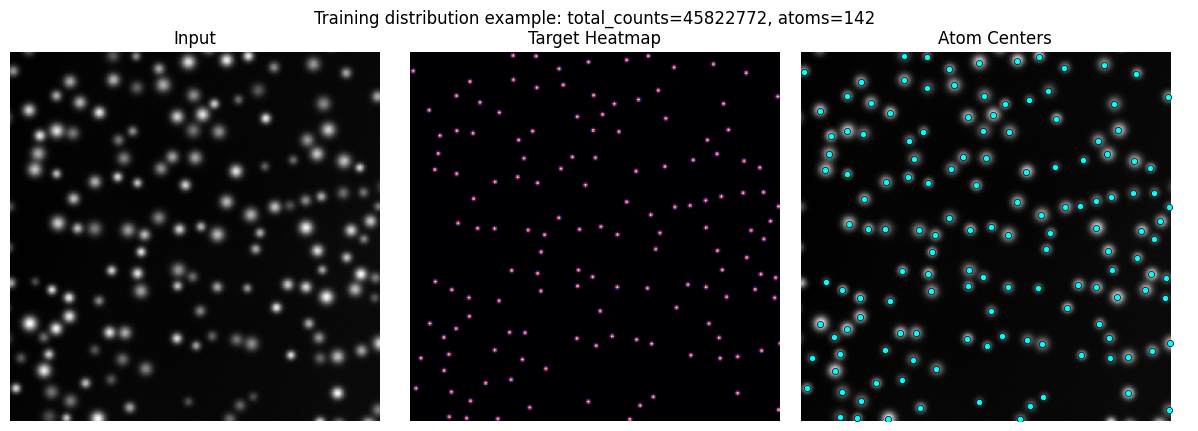

In [3]:
training_image = generate_microscope_image(
    training_config,
    rng=np.random.default_rng(SEED),
)
fig, axes = plot_microscope_image(training_image, figsize=(12, 4))
fig.suptitle(
    f"Training distribution example: total_counts={training_image['total_counts']}, "
    f"atoms={len(training_image['coordinates'])}",
    y=1.04,
)
plt.show()

## Loss Curves

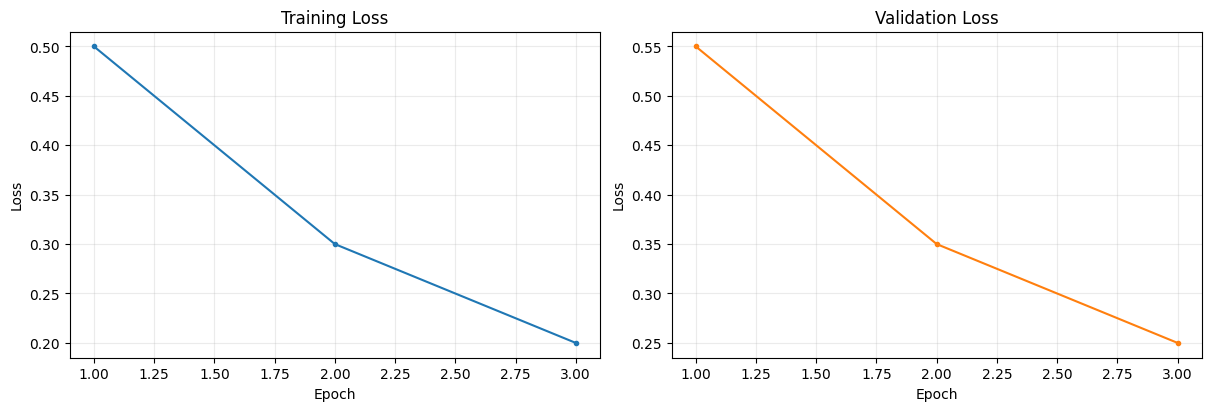

best validation loss: 0.250000 at epoch 3


In [4]:
if not history_path.exists():
    raise FileNotFoundError(
        f"Could not find loss history at {history_path}. "
        "Set RUN_DIR to a completed training run."
    )

history = np.load(history_path)
train_loss = history["train_loss_history"].astype(float)
val_loss = history["val_loss_history"].astype(float)
epochs = np.arange(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(epochs, train_loss, marker="o", linewidth=1.5, markersize=3)
axes[0].set_title("Training Loss")
axes[1].plot(epochs, val_loss, marker="o", linewidth=1.5, markersize=3, color="tab:orange")
axes[1].set_title("Validation Loss")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.25)
plt.show()

print(f"best validation loss: {val_loss.min():.6f} at epoch {int(val_loss.argmin()) + 1}")

## Load Model

In [5]:
if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Could not find checkpoint at {checkpoint_path}. "
        "Set RUN_DIR to a completed training run."
    )

device = resolve_torch_device(DEVICE, verbose=True)
model = build_unet(
    input_channels=1,
    num_classes=1,
    num_filters=NUM_FILTERS,
    dropout=DROPOUT,
)
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print(f"loaded epoch {checkpoint.get('best_epoch', -1) + 1}")
print(f"best val loss in checkpoint: {checkpoint.get('best_val_loss', float('nan')):.6f}")

Using device: mps
loaded epoch 2
best val loss in checkpoint: 0.123000


## Predict On Periodic Lattices

In [6]:
periodic_configs = {
    "cubic": PeriodicLatticeConfig(lattice_type="cubic", **periodic_common),
    "hexagonal": PeriodicLatticeConfig(lattice_type="hexagonal", **periodic_common),
}
periodic_datasets = {
    name: SyntheticMicroscopeDataset(
        num_samples=PERIODIC_SAMPLES,
        config=config,
        seed=SEED + index * 10_000,
        return_metadata=True,
    )
    for index, (name, config) in enumerate(periodic_configs.items())
}
periodic_loaders = {
    name: DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        collate_fn=metadata_collate,
    )
    for name, dataset in periodic_datasets.items()
}

print({name: len(dataset) for name, dataset in periodic_datasets.items()})

{'cubic': 64, 'hexagonal': 64}


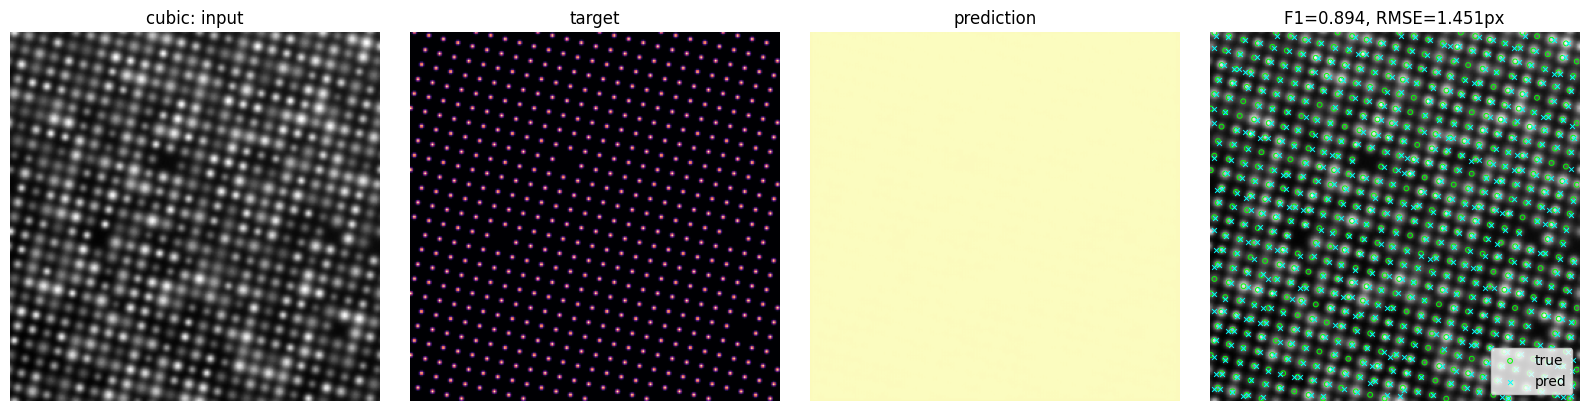

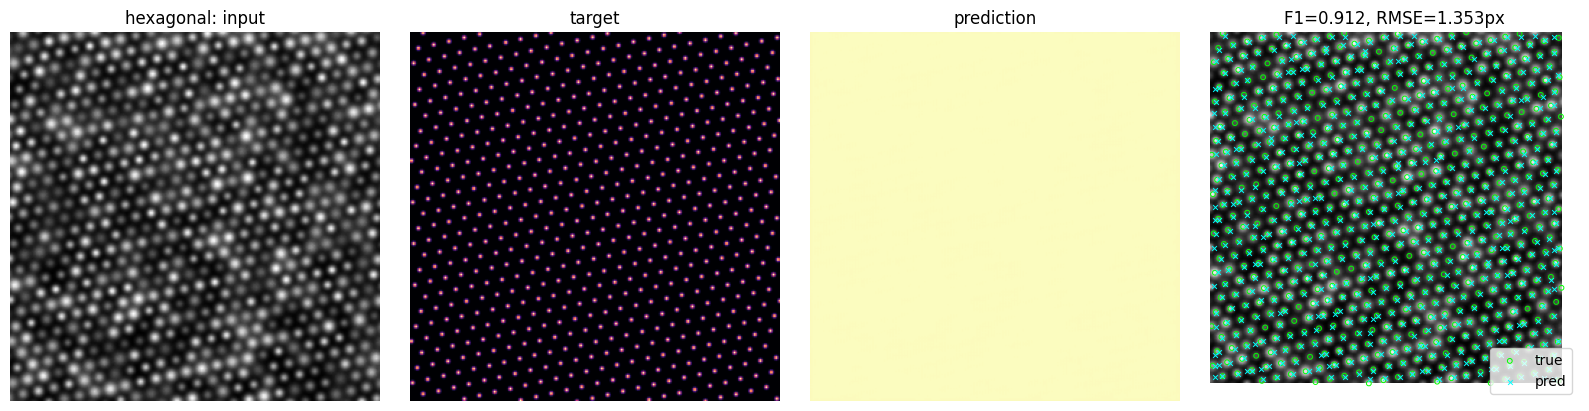

In [7]:
def show_periodic_prediction(case_name: str, sample_index: int = 0) -> dict:
    image, target, metadata = periodic_datasets[case_name][sample_index]
    with torch.no_grad():
        prediction = torch.sigmoid(model(image.unsqueeze(0).to(device)))[0, 0].cpu().numpy()

    result = evaluate_heatmap_localization(
        prediction,
        metadata["coordinates"],
        threshold_rel=THRESHOLD_REL,
        match_distance=MATCH_DISTANCE,
    )

    fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
    axes[0].imshow(image[0].numpy(), cmap="gray")
    axes[0].set_title(f"{case_name}: input")
    axes[1].imshow(target[0].numpy(), cmap="magma", vmin=0, vmax=1)
    axes[1].set_title("target")
    axes[2].imshow(prediction, cmap="magma", vmin=0, vmax=max(float(prediction.max()), 1e-6))
    axes[2].set_title("prediction")
    axes[3].imshow(image[0].numpy(), cmap="gray")
    axes[3].scatter(metadata["coordinates"][:, 1], metadata["coordinates"][:, 0], s=12, facecolors="none", edgecolors="lime", linewidths=0.7, label="true")
    predicted = result["predicted_coordinates"]
    if len(predicted):
        axes[3].scatter(predicted[:, 1], predicted[:, 0], s=12, marker="x", c="cyan", linewidths=0.7, label="pred")
    axes[3].legend(loc="lower right")
    axes[3].set_title(f"F1={result['f1']:.3f}, RMSE={result['rmse']:.3f}px")
    for ax in axes:
        ax.axis("off")
    plt.show()

    return result

prediction_examples = {
    case_name: show_periodic_prediction(case_name, sample_index=0)
    for case_name in ["cubic", "hexagonal"]
}

## Offset Clouds

In [8]:
def collect_periodic_offsets(case_name: str) -> dict:
    model.eval()
    offsets_xy = []
    tp = fp = fn = samples = 0

    with torch.no_grad():
        for images, _targets, metadata_list in periodic_loaders[case_name]:
            predictions = torch.sigmoid(model(images.to(device)))[:, 0].cpu().numpy()
            for heatmap, metadata in zip(predictions, metadata_list):
                result = evaluate_heatmap_localization(
                    heatmap,
                    metadata["coordinates"],
                    threshold_rel=THRESHOLD_REL,
                    match_distance=MATCH_DISTANCE,
                )
                matched_truth = result["matched_truth"]
                matched_predicted = result["matched_predicted"]
                if len(matched_truth):
                    dx = matched_predicted[:, 1] - matched_truth[:, 1]
                    dy = matched_predicted[:, 0] - matched_truth[:, 0]
                    offsets_xy.append(np.stack([dx, dy], axis=1).astype(np.float32))
                tp += int(result["tp"])
                fp += int(result["fp"])
                fn += int(result["fn"])
                samples += 1

    offsets = np.concatenate(offsets_xy, axis=0) if offsets_xy else np.zeros((0, 2), dtype=np.float32)
    errors = np.linalg.norm(offsets, axis=1) if len(offsets) else np.zeros((0,), dtype=np.float32)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2.0 * precision * recall / max(precision + recall, 1e-8)
    return {
        "offsets_xy": offsets,
        "errors": errors,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "samples": samples,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mean_dx": float(offsets[:, 0].mean()) if len(offsets) else float("nan"),
        "mean_dy": float(offsets[:, 1].mean()) if len(offsets) else float("nan"),
        "std_dx": float(offsets[:, 0].std()) if len(offsets) else float("nan"),
        "std_dy": float(offsets[:, 1].std()) if len(offsets) else float("nan"),
        "rmse": float(np.sqrt(np.mean(errors**2))) if len(errors) else float("nan"),
    }


periodic_offsets = {
    case_name: collect_periodic_offsets(case_name)
    for case_name in ["cubic", "hexagonal"]
}

for case_name, data in periodic_offsets.items():
    print(
        f"{case_name}: matched={len(data['offsets_xy'])}, "
        f"F1={float(data['f1']):.4f}, RMSE={float(data['rmse']):.4f}px, "
        f"mean_dx={float(data['mean_dx']):.4f}, mean_dy={float(data['mean_dy']):.4f}"
    )

cubic: matched=32712, F1=0.8666, RMSE=1.4636px, mean_dx=1.0056, mean_dy=0.1331
hexagonal: matched=35645, F1=0.8459, RMSE=1.6217px, mean_dx=1.1773, mean_dy=0.0953


/tmp/blobnet_run/periodic_lattice_notebook/periodic_offset_cloud.png


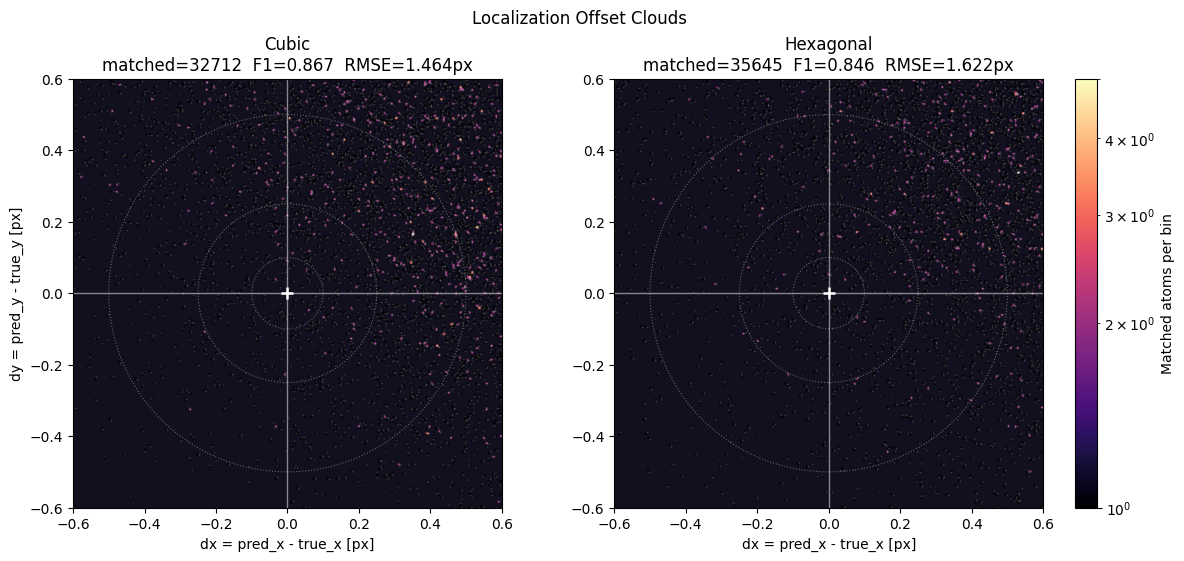

In [9]:
plot_range = 0.6
bins = 181
case_labels = {"cubic": "Cubic", "hexagonal": "Hexagonal"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True)
image_handle = None
for axis_index, case_name in enumerate(["cubic", "hexagonal"]):
    ax = axes[axis_index]
    data = periodic_offsets[case_name]
    offsets = np.asarray(data["offsets_xy"], dtype=np.float32)
    if len(offsets):
        hist, x_edges, y_edges = np.histogram2d(
            offsets[:, 0],
            offsets[:, 1],
            bins=bins,
            range=[[-plot_range, plot_range], [-plot_range, plot_range]],
        )
        image_handle = ax.imshow(
            hist.T,
            extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
            origin="lower",
            cmap="magma",
            norm=LogNorm(vmin=1, vmax=max(float(hist.max()), 1.0)),
        )
        ax.scatter(offsets[:, 0], offsets[:, 1], s=2.0, c="white", alpha=0.18, linewidths=0)
    for radius in [0.1, 0.25, 0.5]:
        ax.add_patch(plt.Circle((0, 0), radius, fill=False, linestyle=":", linewidth=0.8, color="white", alpha=0.35))
    ax.axhline(0, color="white", alpha=0.5, linewidth=1.0)
    ax.axvline(0, color="white", alpha=0.5, linewidth=1.0)
    ax.scatter([0], [0], s=70, c="white", marker="+", linewidths=1.8)
    ax.set_xlim(-plot_range, plot_range)
    ax.set_ylim(-plot_range, plot_range)
    ax.set_xlabel("dx = pred_x - true_x [px]")
    if axis_index == 0:
        ax.set_ylabel("dy = pred_y - true_y [px]")
    ax.set_title(
        f"{case_labels[case_name]}\n"
        f"matched={len(offsets)}  F1={float(data['f1']):.3f}  RMSE={float(data['rmse']):.3f}px"
    )
    ax.set_facecolor("#120f1f")

fig.suptitle("Localization Offset Clouds")
if image_handle is not None:
    fig.colorbar(image_handle, ax=axes.tolist(), fraction=0.025, pad=0.02, label="Matched atoms per bin")
offset_cloud_path = output_dir / "periodic_offset_cloud.png"
fig.savefig(offset_cloud_path, dpi=220, bbox_inches="tight")
print(offset_cloud_path)
plt.show()